In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df = pd.read_csv("/content/synthetic_student_performance.csv")

print(df.shape)
df.head()

(5000, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [3]:

df = df.drop("StudentID", axis=1)


print(df.isnull().sum())
print(df.duplicated().sum())

Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64
0


In [4]:
# Attendance Rate
df["AttendanceRate"] = ((180 - df["Absences"]) / 180) * 100

# Study Category
df["StudyCategory"] = pd.cut(
    df["StudyTimeWeekly"],
    bins=[0, 5, 12, 20],
    labels=[0, 1, 2]
)

# Activity Score
df["ActivityScore"] = (
    df["Extracurricular"] +
    df["Sports"] +
    df["Music"] +
    df["Volunteering"]
)

# Support Score
df["SupportScore"] = (
    df["ParentalSupport"] + df["Tutoring"]
)

# GPA Group
df["GPAGroup"] = pd.cut(
    df["GPA"],
    bins=[2.0, 2.5, 3.0, 3.5, 4.0],
    labels=[0, 1, 2, 3],
    include_lowest=True
)

In [5]:
X = df.drop(columns=["GradeClass","GPAGroup","GPA"])
y = df["GradeClass"]

print(X.shape)
print(y.shape)

(5000, 16)
(5000,)


In [6]:
df["StudyTimeWeekly"] += np.random.normal(0, 2, len(df))
df["Absences"] += np.random.normal(0, 3, len(df))


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (4000, 16)
Testing samples: (1000, 16)


In [8]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [9]:
y_pred = rf.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.433

Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.76      0.63       435
           1       0.24      0.11      0.15       230
           2       0.24      0.17      0.20       205
           3       0.31      0.32      0.31       130

    accuracy                           0.43      1000
   macro avg       0.33      0.34      0.32      1000
weighted avg       0.38      0.43      0.39      1000



In [16]:
y_pred = rf.predict(X_test)


at_risk_pred = np.isin(y_pred, [3, 4]).sum()

print("Predicted At-Risk Students (GradeClass 3 or 4):", at_risk_pred)

Predicted At-Risk Students (GradeClass 3 or 4): 134


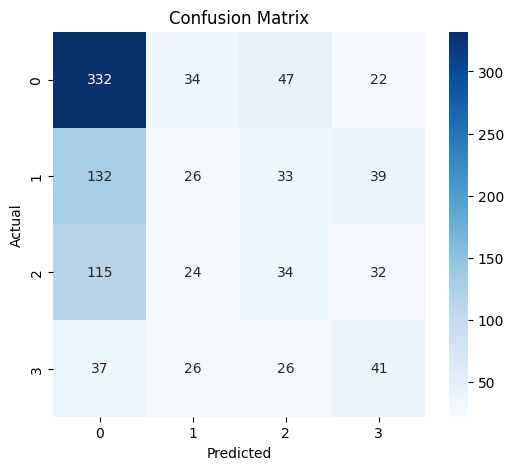

In [12]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

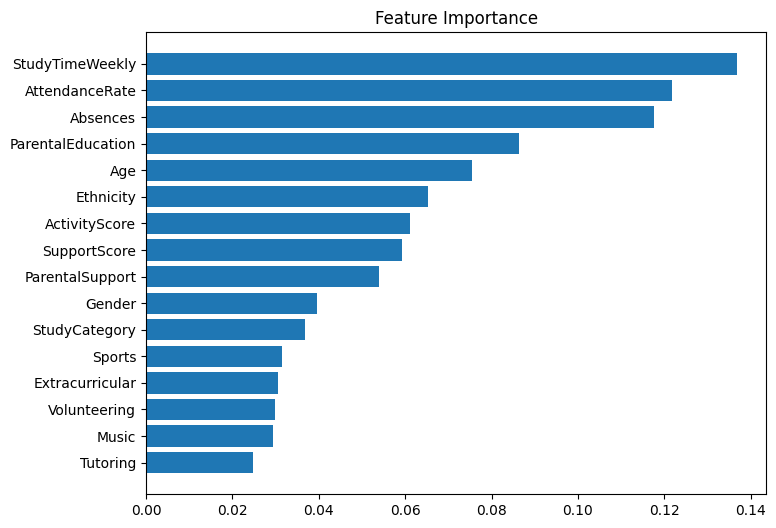

In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8,6))

plt.barh(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")
plt.show()

In [14]:
joblib.dump(rf, "student_performance_model.pkl")

print("Model saved successfully!")


Model saved successfully!
